In [1]:
import sys
import os
pwd = os.getcwd()
sys.path.append(os.path.join(pwd, '..', '..', 'src'))  # course heuristics
sys.path.append(pwd)                                    # objfun_auction.py

%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from objfun_auction import AuctionBidding
from heur_sg import ShootAndGo
from heur_fsa import FastSimulatedAnnealing
from heur_go import GeneticOptimization, RandomCombination
from heur_de import DifferentialEvolution
from heur_aux import CauchyMutation, MirrorCorrection

# Section 1 — Problem Setup & Nash Equilibrium

First-price sealed-bid procurement auction. Lowest bid wins at that price.

- `c_true ~ U[0, 500]` — true cost (hidden)
- `c_obs = clip(c_true + N(0,σ²), 0, 500)` — each bidder's noisy signal
- Profit = `bid − c_true` if win, else 0

**Nash equilibrium (σ=0):** `b*(c) = c + (C_max − c) / N`

**Encoding:** piecewise-linear bid function, `x ∈ [0,1]⁵` (`x[0]` = intercept, `x[1..4]` = segment slopes).  
Oracle is stochastic — each `evaluate()` draws M fresh auctions. `fstar` = 98% of Nash profit.

## Instantiate & inspect

In [3]:
of = AuctionBidding(k=4, N_opps=3, sigma_us=0.0, sigma_opps=[0, 0, 0], M=2000)

print(f"Nash profit  = {of.nash_profit:.4f} $M   (expected profit at Nash equilibrium)")
print(f"Target profit= {-of.fstar:.4f} $M   (success threshold = Nash − 2%)")
print(f"x_nash       = {of.x_nash}")
print(f"domain  a = {of.a}")
print(f"        b = {of.b}   (all dims normalised to [0,1])")
print(f"\nEffective budget (maxeval=1000): {1000 * of.M:,} auction simulations")

Nash profit  = 60.9635 $M   (expected profit at Nash equilibrium)
Target profit= 59.7442 $M   (success threshold = Nash − 2%)
x_nash       = [1.   0.75 0.75 0.75 0.75]
domain  a = [0. 0. 0. 0. 0.]
        b = [1. 1. 1. 1. 1.]   (all dims normalised to [0,1])

Effective budget (maxeval=1000): 2,000,000 auction simulations


## M sweep — oracle noise vs cost

More M = lower variance but slower. Because the success band is *relative* (2% of the optimum), the
quantity to control is the **CV**, not absolute std. σ=50 has ~8× smaller profit, so it needs a larger
M to keep CV under 2% — hence **M=40000** for noisy scenarios vs M=2000 at σ=0.

In [4]:
M_values = [500, 1000, 2000, 5000, 10000, 20000, 40000]
N_seeds  = 100

rows = []
for sigma_label, sigma_kw in [('σ=0',  dict(sigma_us=0,  sigma_opps=[0,0,0])),
                               ('σ=50', dict(sigma_us=50, sigma_opps=[50,50,50]))]:
    for M in tqdm(M_values, desc=f'M sweep {sigma_label}'):
        of_m = AuctionBidding(k=4, N_opps=3, M=M, **sigma_kw)
        vals = []
        for seed in range(N_seeds):
            vals.append(float(of_m.evaluate(of_m.x_nash)))
        v_profit = [-v for v in vals]
        rows.append({'scenario': sigma_label, 'M': M,
                     'mean': float(np.mean(v_profit)),
                     'std':  float(np.std(v_profit)),
                     'cv':   float(np.std(v_profit) / abs(np.mean(v_profit)) * 100)})

df_m = pd.DataFrame(rows)
print(df_m.to_string(index=False))

M sweep σ=0:   0%|          | 0/7 [00:00<?, ?it/s]

M sweep σ=50:   0%|          | 0/7 [00:00<?, ?it/s]

scenario     M      mean      std        cv
     σ=0   500 61.175593 1.309311  2.140251
     σ=0  1000 61.391101 1.249108  2.034672
     σ=0  2000 61.276056 0.729051  1.189781
     σ=0  5000 61.401476 0.564597  0.919517
     σ=0 10000 61.366776 0.377456  0.615082
     σ=0 20000 61.356587 0.261288  0.425852
     σ=0 40000 61.336709 0.175006  0.285321
    σ=50   500  8.289378 1.346293 16.241189
    σ=50  1000  8.081892 1.031638 12.764803
    σ=50  2000  8.243081 0.708600  8.596307
    σ=50  5000  8.186298 0.416465  5.087345
    σ=50 10000  8.138189 0.272401  3.347199
    σ=50 20000  8.172023 0.216418  2.648284
    σ=50 40000  8.159846 0.146572  1.796265


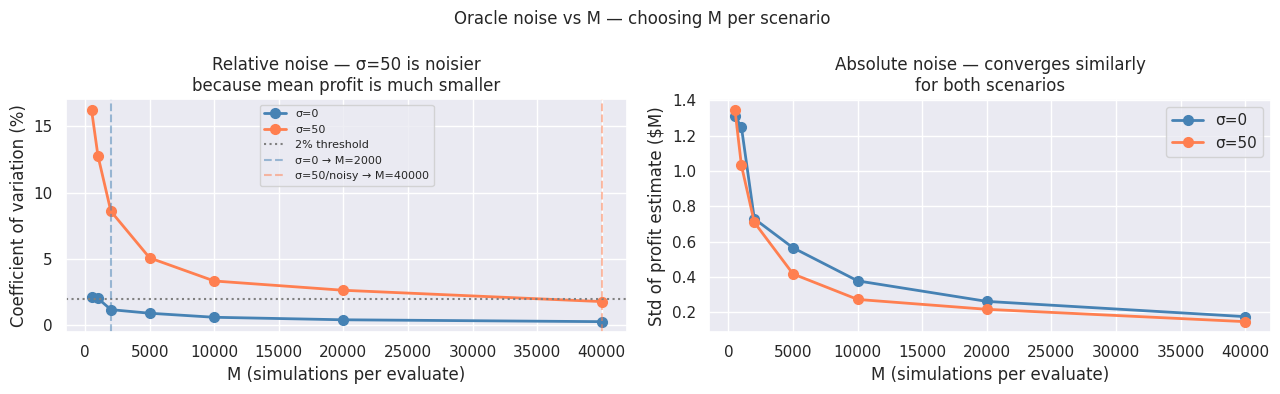

M chosen per scenario so per-evaluate CV stays under the 2% success band:
  sigma=0  -> M=2000  (CV~1.2%)
  noisy    -> M=40000 (CV~1.8%)   [M=10000 gives CV~3.3%, above the band]
The 2% band is a *relative* target, so the relevant precision is relative (CV), not absolute
std. A noisier oracle also inflates the optimistic bias in the search's best_y, so all
cross-strategy conclusions are additionally verified via clean_eval at M=100k (see Section 2).


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
palette = {'σ=0': 'steelblue', 'σ=50': 'coral'}

for ax, metric, ylabel, title in [
    (axes[0], 'cv',  'Coefficient of variation (%)',
     'Relative noise — σ=50 is noisier\nbecause mean profit is much smaller'),
    (axes[1], 'std', 'Std of profit estimate ($M)',
     'Absolute noise — converges similarly\nfor both scenarios'),
]:
    for label, grp in df_m.groupby('scenario'):
        ax.plot(grp['M'], grp[metric], 'o-', label=label,
                color=palette[label], linewidth=2, markersize=7)
    ax.set_xlabel('M (simulations per evaluate)')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

axes[0].axhline(2.0, color='grey', linestyle=':', label='2% threshold')
axes[0].axvline(2000,  color='steelblue', linestyle='--', alpha=0.5, label='σ=0 → M=2000')
axes[0].axvline(40000, color='coral',     linestyle='--', alpha=0.5, label='σ=50/noisy → M=40000')
axes[0].legend(fontsize=8)

plt.suptitle('Oracle noise vs M — choosing M per scenario', fontsize=12)
plt.tight_layout()
plt.show()

cv0  = df_m[(df_m.scenario == 'σ=0')  & (df_m.M == 2000)]['cv'].iloc[0]
cv50 = df_m[(df_m.scenario == 'σ=50') & (df_m.M == 40000)]['cv'].iloc[0]
print("M chosen per scenario so per-evaluate CV stays under the 2% success band:")
print(f"  sigma=0  -> M=2000  (CV~{cv0:.1f}%)")
print(f"  noisy    -> M=40000 (CV~{cv50:.1f}%)   [M=10000 gives CV~3.3%, above the band]")
print("The 2% band is a *relative* target, so the relevant precision is relative (CV), not absolute")
print("std. A noisier oracle also inflates the optimistic bias in the search's best_y, so all")
print("cross-strategy conclusions are additionally verified via clean_eval at M=100k (see Section 2).")

## Nash bid function (σ=0, N=4)

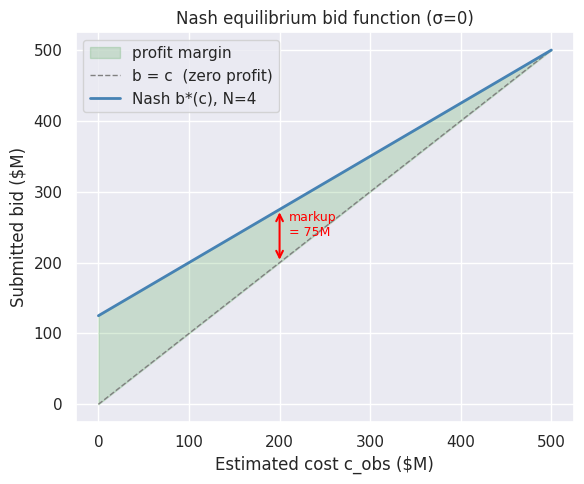

In [6]:
C_max = 500.0
N = 4
c_vals = np.linspace(0, C_max, 300)
b_nash = c_vals + (C_max - c_vals) / N

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(c_vals, c_vals, b_nash, alpha=0.15, color='green', label='profit margin')
ax.plot(c_vals, c_vals,  '--', color='grey',  linewidth=1, label='b = c  (zero profit)')
ax.plot(c_vals, b_nash,  '-',  color='steelblue', linewidth=2, label=f'Nash b*(c), N={N}')
ax.annotate('', xy=(200, 275), xytext=(200, 200),
            arrowprops=dict(arrowstyle='<->', color='red', lw=1.5))
ax.text(210, 237, 'markup\n= 75M', color='red', fontsize=9)
ax.set_xlabel('Estimated cost c_obs ($M)')
ax.set_ylabel('Submitted bid ($M)')
ax.set_title('Nash equilibrium bid function (σ=0)')
ax.legend()
plt.tight_layout()

## Sanity check — RS on σ=0

Random Shooting should recover a bid function near the Nash line.

In [7]:
result_rs = ShootAndGo(of, maxeval=500, hmax=0, seed=0).search()
x_learned = result_rs['best_x']

rs_profit   = -result_rs['best_y']
nash_profit = of.nash_profit
print(f"RS profit   = {rs_profit:.4f} $M")
print(f"Nash profit = {nash_profit:.4f} $M")
print(f"Gap         = {nash_profit - rs_profit:.4f} $M  ({(nash_profit - rs_profit)/nash_profit*100:.1f}% below Nash)")
print(f"Success     = {result_rs['success']}")
print(f"x_learned   = {x_learned}")
print(f"x_nash      = {of.x_nash}")

RS profit   = 50.4530 $M
Nash profit = 60.9635 $M
Gap         = 10.5105 $M  (17.2% below Nash)
Success     = False
x_learned   = [0.83704703 0.77824823 0.88848989 0.63149152 0.35636455]
x_nash      = [1.   0.75 0.75 0.75 0.75]


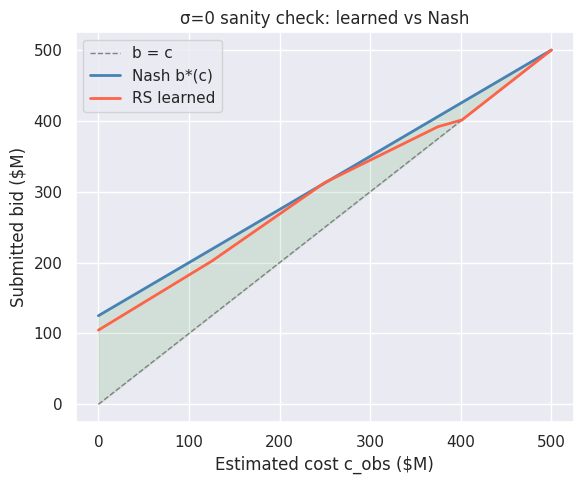

In [8]:
def bid_curve(of, x, c_vals):
    return np.array([of._decode(x, c) for c in c_vals])

fig, ax = plt.subplots(figsize=(6, 5))
ax.fill_between(c_vals, c_vals, b_nash, alpha=0.10, color='green')
ax.plot(c_vals, c_vals,   '--', color='grey',     linewidth=1,   label='b = c')
ax.plot(c_vals, b_nash,   '-',  color='steelblue', linewidth=2,  label='Nash b*(c)')
ax.plot(c_vals, bid_curve(of, x_learned, c_vals),
                           '-',  color='tomato',    linewidth=2,  label='RS learned')
ax.set_xlabel('Estimated cost c_obs ($M)')
ax.set_ylabel('Submitted bid ($M)')
ax.set_title('σ=0 sanity check: learned vs Nash')
ax.legend()
plt.tight_layout()

σ=0 sanity check passes. Sections 2–5 explore noisy markets where Nash is no longer optimal.

## Section 2 — Algorithm Comparison (σ=0)

The oracle is **stochastic**: each `evaluate()` is one Monte-Carlo draw of `M=2000` auctions, so the
returned `best_y` (a min over noisy draws) is **optimistically biased**. We therefore report
**REL (in-search)** (the noisy success flag) vs **REL (verified)** (`best_x` re-scored on `M=100k`
fresh auctions via `clean_eval`). Budget: `maxeval=1000 × M=2000` = 2M sims/run.

In [9]:
MAXEVAL  = 1000
N_SEEDS  = 100
M_EVAL   = 100000   # clean oracle: re-score best_x with 50x more auctions to remove the
                    # optimistic selection bias in the heuristics' noisy in-search best_y

of0 = AuctionBidding(k=4, N_opps=3, sigma_us=0.0, sigma_opps=[0, 0, 0], M=2000)
print(f"Target profit (fstar) = {-of0.fstar:.3f} $M  (98% of Nash {of0.nash_profit:.3f})")

def compute_stats(results, of):
    df = pd.DataFrame([
        {'in_profit': -r['best_y'],                               # noisy in-search estimate
         'profit':    of.clean_eval(r['best_x'], M_eval=M_EVAL),  # unbiased re-evaluation
         'neval':     r['neval'],
         'hit':       r['success']}                               # in-search flag (lucky-draw prone)
        for r in results
    ])
    df['success'] = df['profit'] >= -of.fstar          # verified: true profit within the 2% band
    rel_in = df['hit'].mean()                          # in-search reliability (optimistic)
    rel    = df['success'].mean()                      # verified reliability
    mne = df.loc[df['hit'], 'neval'].mean() if rel_in > 0 else np.nan
    feo = mne / rel_in if rel_in > 0 else np.nan       # cost per in-search success (optimistic)
    return {'REL_insearch': rel_in, 'REL_verified': rel, 'MNE': mne, 'FEO': feo,
            'Median profit': df['profit'].median(),
            'Bias': df['in_profit'].mean() - df['profit'].mean()}

def make_rs(seed):
    return ShootAndGo(of0, maxeval=MAXEVAL, hmax=0, seed=seed)

def make_fsa(seed):
    return FastSimulatedAnnealing(of0, maxeval=MAXEVAL, T0=1, n0=30, alpha=2,
        mutation=CauchyMutation(r=0.02, correction=MirrorCorrection(of0)), seed=seed)

def make_go(seed):
    return GeneticOptimization(of0, maxeval=MAXEVAL, N=10, M=20, Tsel1=1.0, Tsel2=2.0,
        mutation=CauchyMutation(r=0.02, correction=MirrorCorrection(of0)),
        crossover=RandomCombination(), seed=seed)

def make_de(seed):
    return DifferentialEvolution(of0, maxeval=MAXEVAL, N=10, CR=0.9, F=0.8,
        mutation='rand/1', seed=seed)

results = {name: [factory(s).search() for s in tqdm(range(N_SEEDS), desc=name)]
           for name, factory in [('RS', make_rs), ('FSA', make_fsa),
                                 ('GO', make_go), ('DE', make_de)]}
stats_df = pd.DataFrame({name: compute_stats(r, of0) for name, r in results.items()}).T
print(stats_df.round(2))

Target profit (fstar) = 59.744 $M  (98% of Nash 60.964)


RS:   0%|          | 0/100 [00:00<?, ?it/s]

FSA:   0%|          | 0/100 [00:00<?, ?it/s]

GO:   0%|          | 0/100 [00:00<?, ?it/s]

DE:   0%|          | 0/100 [00:00<?, ?it/s]

     REL_insearch  REL_verified     MNE     FEO  Median profit  Bias
RS           0.00          0.00     NaN     NaN          52.03  0.40
FSA          0.69          0.14  446.22  646.69          58.76  1.24
GO           0.76          0.19  510.26  671.40          58.98  1.10
DE           0.80          0.13  564.21  705.27          58.42  1.57


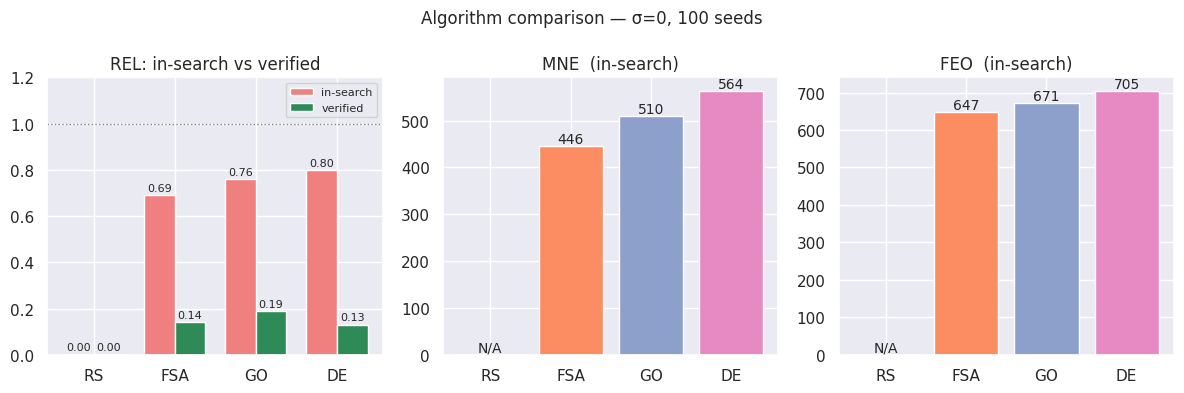

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
alg_names = list(stats_df.index)
colors    = sns.color_palette('Set2', len(alg_names))
x = np.arange(len(alg_names))

# Panel 0: reliability — in-search (optimistic) vs verified (clean re-eval)
ax = axes[0]
w = 0.38
b1 = ax.bar(x - w/2, stats_df['REL_insearch'].astype(float), w, label='in-search', color='lightcoral')
b2 = ax.bar(x + w/2, stats_df['REL_verified'].astype(float), w, label='verified',  color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(alg_names)
ax.set_ylim(0, 1.2); ax.axhline(1.0, color='grey', linestyle=':', lw=1)
ax.set_title('REL: in-search vs verified'); ax.legend(fontsize=8)
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

# Panels 1-2: MNE and FEO (based on in-search success -> optimistic)
for ax, metric in zip(axes[1:], ['MNE', 'FEO']):
    vals = stats_df[metric].values.astype(float)
    bars = ax.bar(alg_names, np.nan_to_num(vals, nan=0.0), color=colors)
    ax.set_title(metric + '  (in-search)')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.0f}' if not np.isnan(v) else 'N/A', ha='center', va='bottom', fontsize=10)

plt.suptitle(f'Algorithm comparison — σ=0, {N_SEEDS} seeds', fontsize=12)
plt.tight_layout()

**Algorithm assessment (σ=0, 100 seeds):**

| | RS | FSA | GO | DE |
|---|---|---|---|---|
| REL (in-search) | 0% | 69% | 76% | 80% |
| **REL (verified)** | 0% | **14%** | **19%** | **13%** |
| Optimistic bias ($M) | 0.4 | 1.24 | 1.10 | 1.57 |
| FEO (in-search) | — | 647 | 671 | 705 |
| Median profit (verified) | 52.0 | 58.8 | 59.0 | 58.4 |

- **Noisy oracle inflates REL** — in-search success fires far more than verified confirms (FSA 69→14%, GO 76→19%, DE 80→13%): the search stops on a lucky draw. Bias ~1.1–1.6 $M > the 2% band (1.22 $M), so the verified column is the honest one.
- **DE is the cautionary case** — highest in-search REL, lowest verified: a population overfits lucky draws hardest.
- **RS fails** (0 successes); **FSA/GO/DE tie** on verified profit (~58–59 $M ≈ 96% of Nash).
- **FSA chosen** — simplest, lowest bias, same verified profit; used for all noisy scenarios.

### FSA hyperparameter tuning

We tune FSA's four knobs (`r`, `T0`, `n0`, `alpha`) one at a time around the defaults, scoring each by
verified profit (clean oracle).

FSA r:   0%|          | 0/5 [00:00<?, ?it/s]

FSA T0:   0%|          | 0/4 [00:00<?, ?it/s]

FSA n0:   0%|          | 0/3 [00:00<?, ?it/s]

FSA alpha:   0%|          | 0/3 [00:00<?, ?it/s]


[r]  default=0.02   best verified median @ r=0.05
 value    median       p25       p75      rel
 0.005 56.172892 54.242646 57.092531 0.033333
 0.010 57.650765 56.694712 58.698822 0.033333
 0.020 58.446334 56.867457 58.960697 0.066667
 0.050 58.457476 57.528950 59.107521 0.066667
 0.100 56.798901 56.032919 58.375541 0.066667

[T0]  default=1   best verified median @ T0=3.0
 value    median       p25       p75      rel
   0.3 58.346810 57.404249 58.807194 0.100000
   1.0 58.446334 56.867457 58.960697 0.066667
   3.0 58.556440 57.797543 59.041679 0.066667
  10.0 58.340886 57.686364 59.184230 0.100000

[n0]  default=30   best verified median @ n0=10
 value    median       p25       p75      rel
    10 58.794697 57.735239 59.504076 0.166667
    30 58.446334 56.867457 58.960697 0.066667
   100 58.658236 58.165289 59.168517 0.066667

[alpha]  default=2   best verified median @ alpha=3
 value    median       p25       p75      rel
     1 58.234127 57.645642 59.159010 0.100000
     2 58.446334

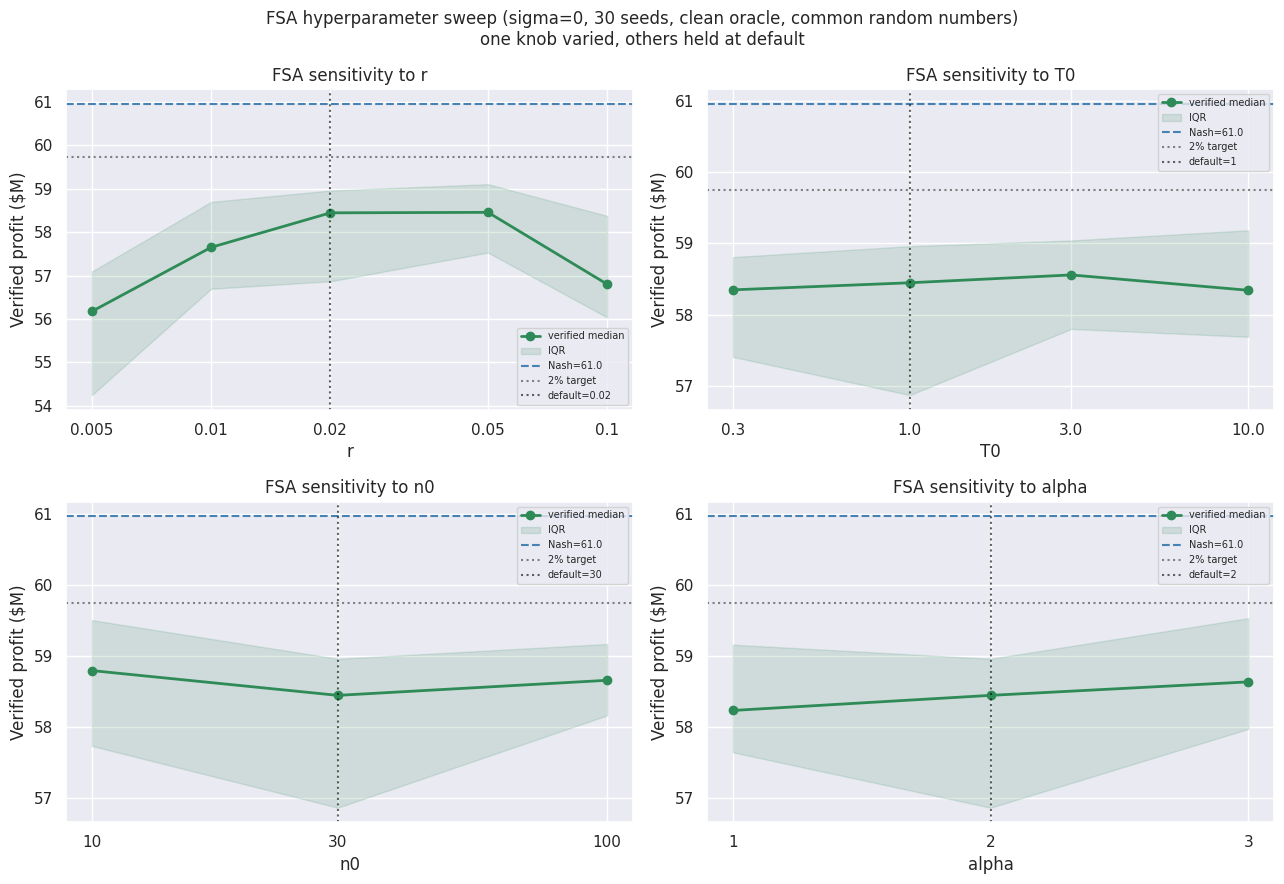

In [11]:
# FSA hyperparameter sweep — one knob at a time around the defaults (T0=1, n0=30, alpha=2, r=0.02).
# Each configuration is scored on a FRESH, fixed-seed oracle so every setting sees the *same* auction
# draws (common random numbers) and the default point is identical across all four panels.
TUNE_SEEDS = 30
DEFAULTS = dict(T0=1, n0=30, alpha=2, r=0.02)
GRIDS = {
    'r':     [0.005, 0.01, 0.02, 0.05, 0.1],
    'T0':    [0.3, 1, 3, 10],
    'n0':    [10, 30, 100],
    'alpha': [1, 2, 3],
}

def fsa_verified(of_t, params, seed):
    h = FastSimulatedAnnealing(of_t, maxeval=MAXEVAL, T0=params['T0'], n0=params['n0'],
            alpha=params['alpha'],
            mutation=CauchyMutation(r=params['r'], correction=MirrorCorrection(of_t)), seed=seed)
    return of_t.clean_eval(h.search()['best_x'], M_eval=M_EVAL)

sweep = {}
for knob, values in GRIDS.items():
    rows = []
    for v in tqdm(values, desc=f'FSA {knob}'):
        params = dict(DEFAULTS); params[knob] = v
        of_t = AuctionBidding(k=4, N_opps=3, sigma_us=0.0, sigma_opps=[0, 0, 0], M=2000)
        vp = np.array([fsa_verified(of_t, params, s) for s in range(TUNE_SEEDS)])
        rows.append({'value': v, 'median': np.median(vp),
                     'p25': np.percentile(vp, 25), 'p75': np.percentile(vp, 75),
                     'rel': float((vp >= -of0.fstar).mean())})
    sweep[knob] = pd.DataFrame(rows)

for knob, dfk in sweep.items():
    best = dfk.loc[dfk['median'].idxmax(), 'value']
    print(f"\n[{knob}]  default={DEFAULTS[knob]}   best verified median @ {knob}={best}")
    print(dfk.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (knob, dfk) in zip(axes.flat, sweep.items()):
    xs = dfk['value'].astype(float).values
    ax.plot(xs, dfk['median'], 'o-', color='seagreen', lw=2, label='verified median')
    ax.fill_between(xs, dfk['p25'], dfk['p75'], color='seagreen', alpha=0.15, label='IQR')
    ax.axhline(of0.nash_profit, color='steelblue', ls='--', label=f'Nash={of0.nash_profit:.1f}')
    ax.axhline(-of0.fstar, color='grey', ls=':', label='2% target')
    ax.axvline(DEFAULTS[knob], color='black', ls=':', alpha=0.6, label=f'default={DEFAULTS[knob]}')
    if knob in ('r', 'T0', 'n0'):
        ax.set_xscale('log')
    ax.set_xticks(xs); ax.set_xticklabels(dfk['value'].values)
    ax.set_xlabel(knob); ax.set_ylabel('Verified profit ($M)')
    ax.set_title(f'FSA sensitivity to {knob}')
    ax.legend(fontsize=7)
fig.suptitle(f'FSA hyperparameter sweep (sigma=0, {TUNE_SEEDS} seeds, clean oracle, common random numbers)\n'
             'one knob varied, others held at default', fontsize=12)
plt.tight_layout(); plt.show()

**Verdict — FSA is robust.** The default (`T0=1, n0=30, alpha=2, r=0.02`) scores a **58.45 $M** verified median.

- **`r`** is the only knob that matters, and only at extremes: a plateau over `[0.02, 0.05]`; `r=0.005`/`0.1` are worse.
- **`T0`, `n0`, `alpha`** move the verified median by ≤0.4 $M — inside the seed IQR, i.e. noise.

The defaults are a safe, near-optimal choice.

### Is M sufficient? — M as a budget multiplier

CV always falls with M, so it cannot tell us if M is *sufficient*. The honest test holds the **total
budget `maxeval × M` fixed** and varies the split (each run = 2M sims, early stopping disabled, `best_x`
scored clean). M is sufficient where verified quality stops improving.

In [12]:
# Fixed total-simulation budget: vary the maxeval / M split, measure VERIFIED quality.
BUDGET   = 2_000_000          # auction sims per run (= Section 2: maxeval 1000 x M 2000)
N_SPLITS = 30                 # seeds per split
SPLIT_M  = [250, 500, 1000, 2000, 4000, 8000]
target   = of0.nash_profit * (1 - 0.02)   # 2% band, same threshold as fstar

split_rows = []
for M in tqdm(SPLIT_M, desc='M split sweep'):
    maxeval_m = BUDGET // M
    of_m = AuctionBidding(k=4, N_opps=3, sigma_us=0.0, sigma_opps=[0, 0, 0], M=M)
    of_m.fstar = -np.inf      # disable early stop -> every run spends the full budget
    verified = []
    for seed in range(N_SPLITS):
        h = FastSimulatedAnnealing(of_m, maxeval=maxeval_m, T0=1, n0=30, alpha=2,
                mutation=CauchyMutation(r=0.02, correction=MirrorCorrection(of_m)), seed=seed)
        r = h.search()
        verified.append(of_m.clean_eval(r['best_x'], M_eval=100000))
    verified = np.array(verified)
    split_rows.append({'M': M, 'maxeval': maxeval_m,
                       'median': np.median(verified),
                       'p25': np.percentile(verified, 25),
                       'p75': np.percentile(verified, 75),
                       'rel': float((verified >= target).mean())})

df_split = pd.DataFrame(split_rows)
print(f"Fixed budget = {BUDGET:,} sims/run   |   Nash = {of0.nash_profit:.2f},  2% target = {target:.2f}")
print(df_split.to_string(index=False))

M split sweep:   0%|          | 0/6 [00:00<?, ?it/s]

Fixed budget = 2,000,000 sims/run   |   Nash = 60.96,  2% target = 59.74
   M  maxeval    median       p25       p75      rel
 250     8000 57.061975 55.742311 58.436476 0.133333
 500     4000 58.748495 57.031436 59.972879 0.300000
1000     2000 58.631103 57.943602 59.232987 0.233333
2000     1000 59.013480 57.355367 60.062729 0.333333
4000      500 58.177322 57.066456 59.103306 0.166667
8000      250 57.165304 52.828558 58.400805 0.000000


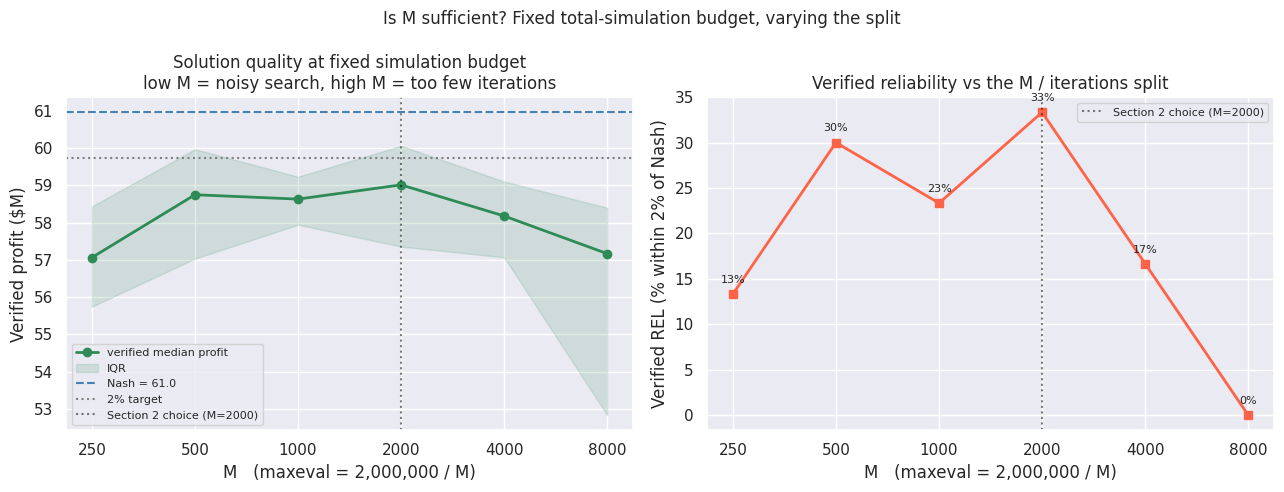

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
Ms = df_split['M'].values

ax = axes[0]
ax.plot(Ms, df_split['median'], 'o-', color='seagreen', lw=2, label='verified median profit')
ax.fill_between(Ms, df_split['p25'], df_split['p75'], color='seagreen', alpha=0.15, label='IQR')
ax.axhline(of0.nash_profit, color='steelblue', ls='--', label=f'Nash = {of0.nash_profit:.1f}')
ax.axhline(target, color='grey', ls=':', label='2% target')
ax.axvline(2000, color='black', ls=':', alpha=0.5, label='Section 2 choice (M=2000)')
ax.set_xscale('log'); ax.set_xticks(Ms); ax.set_xticklabels(Ms)
ax.set_xlabel('M   (maxeval = 2,000,000 / M)')
ax.set_ylabel('Verified profit ($M)')
ax.set_title('Solution quality at fixed simulation budget\nlow M = noisy search, high M = too few iterations')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(Ms, df_split['rel'] * 100, 's-', color='tomato', lw=2)
ax.axvline(2000, color='black', ls=':', alpha=0.5, label='Section 2 choice (M=2000)')
ax.set_xscale('log'); ax.set_xticks(Ms); ax.set_xticklabels(Ms)
ax.set_xlabel('M   (maxeval = 2,000,000 / M)')
ax.set_ylabel('Verified REL (% within 2% of Nash)')
ax.set_title('Verified reliability vs the M / iterations split')
for x_, y_ in zip(Ms, df_split['rel'] * 100):
    ax.annotate(f'{y_:.0f}%', (x_, y_), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.legend(fontsize=8)

plt.suptitle('Is M sufficient? Fixed total-simulation budget, varying the split', fontsize=12)
plt.tight_layout()
plt.show()

**Verdict — M=2000 is the sweet spot.**

- **Interior optimum** — too small → search misled by noise; too large → too few iterations (M=8000 → 0% verified). Verified quality peaks at M≈500–2000.
- **CV alone can't choose M** — at a fixed budget, more M starves iterations; the criterion is verified quality at constant cost.
- **Noisy scenarios use M=40000** because there the CV<2% floor is *binding* (at σ=0 it isn't), and FSA's ~600-eval convergence leaves iteration headroom.
- **Early stopping hurts twice** — full-budget runs reach 33% REL vs 14% early-stopped.

## Section 3 — Market Composition Sweep

8 scenarios — **2×4 grid**: rows = σ_us ∈ {0, 50}, columns = opponent noise (0 → 1 → 2 → 3 noisy opps).

In [14]:
M_NOISY = 40000  # noisy scenarios: M chosen so per-evaluate CV < 2% (see Section 1); M=10000 gives CV~3.3%

# 2×4 grid: rows = σ_us ∈ {0, 50}, columns = opponent noise ∈ {0, 1, 2, 3 noisy opps}
SCENARIOS_LIST = [
    # ── σ_us = 0 : our cost signal is accurate ──────────────────────────────
    ('us0_opp000',  'σ_us=0 | opps σ=0',        dict(sigma_us=0,  sigma_opps=[0,  0,  0 ], M=2000   )),
    ('us0_opp005',  'σ_us=0 | 1 noisy opp',     dict(sigma_us=0,  sigma_opps=[0,  0,  50], M=M_NOISY)),
    ('us0_opp055',  'σ_us=0 | 1 expert opp',    dict(sigma_us=0,  sigma_opps=[0,  50, 50], M=M_NOISY)),
    ('us0_opp555',  'σ_us=0 | all opps σ=50',   dict(sigma_us=0,  sigma_opps=[50, 50, 50], M=M_NOISY)),
    # ── σ_us = 50 : our cost signal is noisy ────────────────────────────────
    ('us50_opp000', 'σ_us=50 | opps σ=0',       dict(sigma_us=50, sigma_opps=[0,  0,  0 ], M=M_NOISY)),
    ('us50_opp005', 'σ_us=50 | 1 noisy opp',    dict(sigma_us=50, sigma_opps=[0,  0,  50], M=M_NOISY)),
    ('us50_opp055', 'σ_us=50 | 1 expert opp',   dict(sigma_us=50, sigma_opps=[0,  50, 50], M=M_NOISY)),
    ('us50_opp555', 'σ_us=50 | all σ=50',       dict(sigma_us=50, sigma_opps=[50, 50, 50], M=M_NOISY)),
]
N_S3 = 50

def fsa_best_curve(result, maxeval):
    """Returns best profit found so far at each evaluation step (positive, non-decreasing)."""
    log = result['log_data']
    if len(log) == 0:
        return np.full(maxeval, -result['best_y'])
    all_f = np.concatenate([[log['f_x'].iloc[0]], log['f_y'].values])
    curve = -np.minimum.accumulate(all_f)   # negate: profit goes up as search improves
    if len(curve) < maxeval:
        curve = np.pad(curve, (0, maxeval - len(curve)), mode='edge')
    return curve[:maxeval]

s3_results = {}
for name, label, kw in tqdm(SCENARIOS_LIST, desc='scenarios'):
    of_s = AuctionBidding(k=4, N_opps=3, **kw)
    runs = []
    for seed in range(N_S3):
        h = FastSimulatedAnnealing(of_s, maxeval=MAXEVAL, T0=1, n0=30, alpha=2,
                mutation=CauchyMutation(r=0.02, correction=MirrorCorrection(of_s)), seed=seed)
        r = h.search()
        runs.append(r)
    s3_results[name] = runs

scenarios:   0%|          | 0/8 [00:00<?, ?it/s]

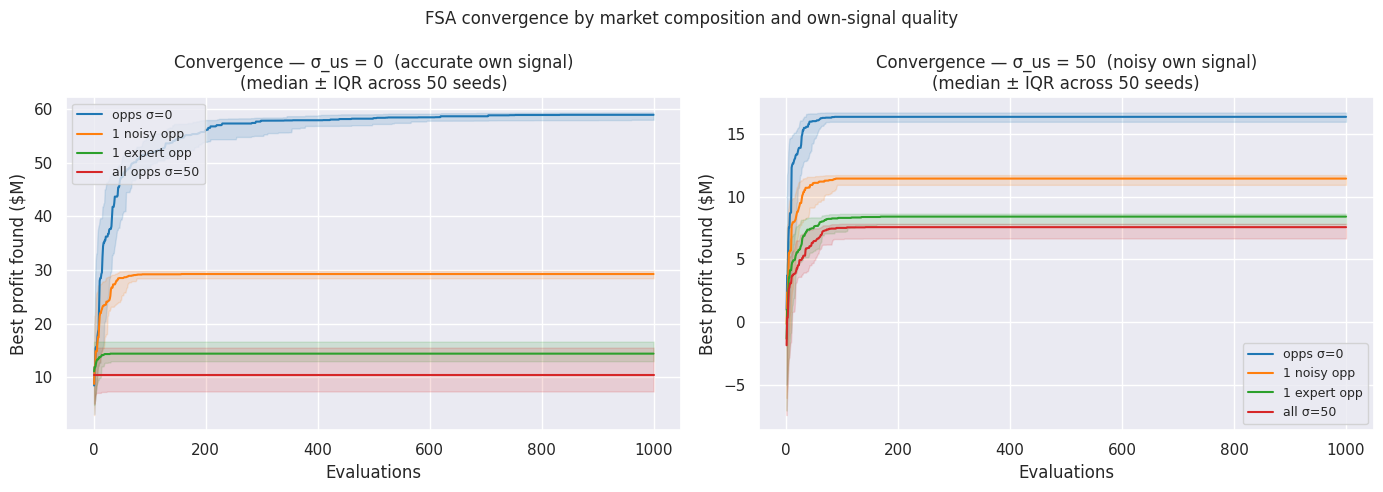

/tmp/ipykernel_23692/1464246727.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_g, labels=labels_g, vert=True)
/tmp/ipykernel_23692/1464246727.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data_g, labels=labels_g, vert=True)


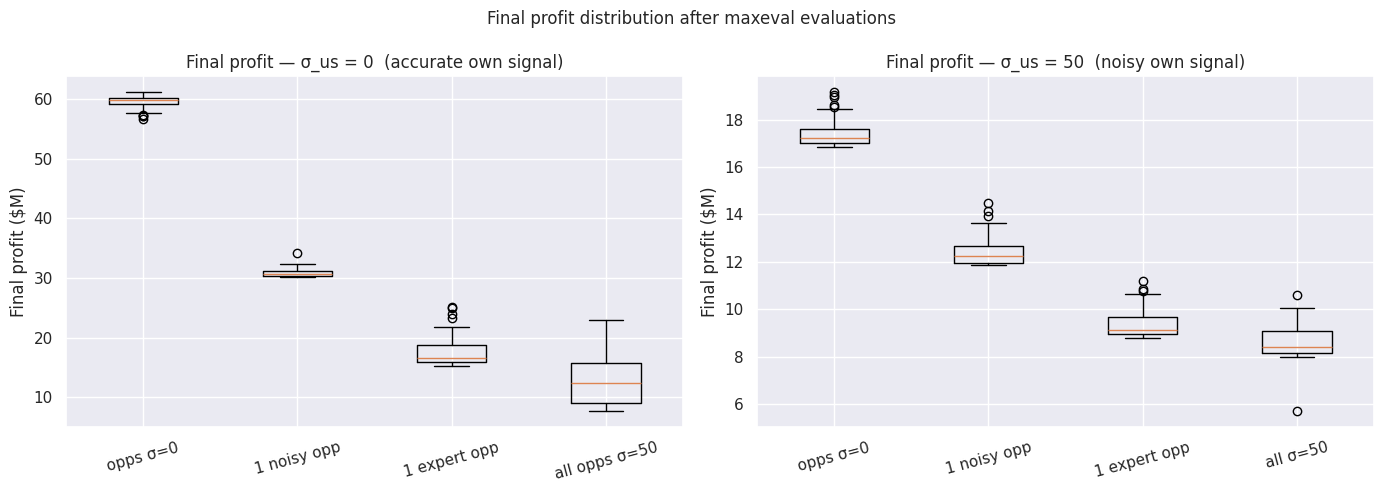

In [15]:
# Split convergence curves into two panels: σ_us=0 (left) vs σ_us=50 (right)
groups = [
    ('σ_us = 0  (accurate own signal)', SCENARIOS_LIST[:4]),
    ('σ_us = 50  (noisy own signal)',   SCENARIOS_LIST[4:]),
]
palette4 = sns.color_palette('tab10', 4)
xs = np.arange(1, MAXEVAL + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (group_title, group) in zip(axes, groups):
    for (name, label, _), col in zip(group, palette4):
        curves = np.array([fsa_best_curve(r, MAXEVAL) for r in s3_results[name]])
        med = np.median(curves, axis=0)
        p25 = np.percentile(curves, 25, axis=0)
        p75 = np.percentile(curves, 75, axis=0)
        short_label = label.split('|')[1].strip()
        ax.plot(xs, med, color=col, label=short_label)
        ax.fill_between(xs, p25, p75, color=col, alpha=0.15)
    ax.set_xlabel('Evaluations')
    ax.set_ylabel('Best profit found ($M)')
    ax.set_title(f'Convergence — {group_title}\n(median ± IQR across {N_S3} seeds)')
    ax.legend(fontsize=9)

plt.suptitle('FSA convergence by market composition and own-signal quality', fontsize=12)
plt.tight_layout()
plt.show()

# Final profit boxplot (all 8 scenarios, split by σ_us group)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax, (group_title, group) in zip(axes, groups):
    labels_g = [label.split('|')[1].strip() for _, label, _ in group]
    data_g   = [[-r['best_y'] for r in s3_results[name]] for name, _, _ in group]
    ax.boxplot(data_g, labels=labels_g, vert=True)
    ax.set_ylabel('Final profit ($M)')
    ax.set_title(f'Final profit — {group_title}')
    ax.tick_params(axis='x', rotation=15)
plt.suptitle('Final profit distribution after maxeval evaluations', fontsize=12)
plt.tight_layout()
plt.show()

## Section 4 — Nash vs Optimised Strategy

Nash is optimal only at σ=0. We compare each scenario's **verified** FSA profit against the Nash
baseline. Three regimes: with an accurate own signal FSA *exploits* noisy opponents and beats Nash;
when we are the noisy party it only matches Nash; at σ=0 it correctly cannot beat Nash (precision-limited).

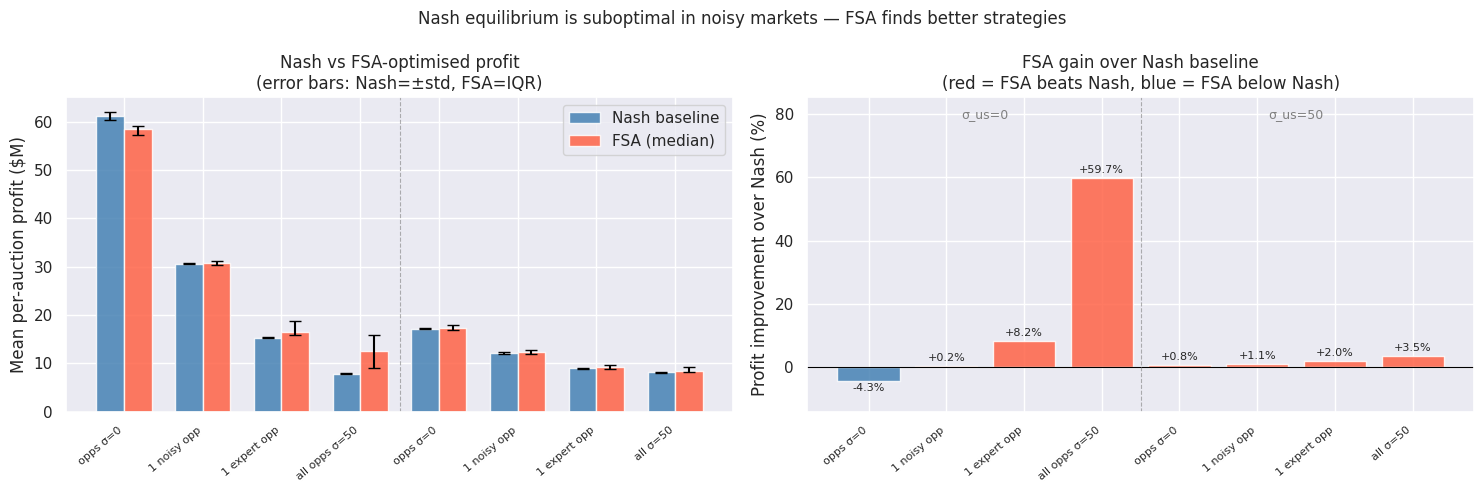


Scenario                              Nash   FSA med      Gain    Gain%
----------------------------------------------------------------------
σ_us=0 | opps σ=0                    61.25     58.62     -2.63    -4.3%
σ_us=0 | 1 noisy opp                 30.65     30.71     +0.07    +0.2%
σ_us=0 | 1 expert opp                15.33     16.59     +1.26    +8.2%
σ_us=0 | all opps σ=50                7.82     12.50     +4.67   +59.7%
σ_us=50 | opps σ=0                   17.21     17.34     +0.13    +0.8%
σ_us=50 | 1 noisy opp                12.13     12.26     +0.13    +1.1%
σ_us=50 | 1 expert opp                8.99      9.17     +0.18    +2.0%
σ_us=50 | all σ=50                    8.16      8.44     +0.28    +3.5%


In [16]:
N_NASH_DRAWS = 50   # independent MC draws to get stable Nash profit per scenario

rows = []
for name, label, kw in SCENARIOS_LIST:
    of_s = AuctionBidding(k=4, N_opps=3, **kw)
    nash_profits = [np.mean(of_s._mc_raw(of_s.x_nash)) for _ in range(N_NASH_DRAWS)]
    nash_mean = np.mean(nash_profits)
    nash_std  = np.std(nash_profits)

    # verified profit: re-score each best_x with the clean oracle (unbiased),
    # consistent with Section 2 — the in-search best_y is optimistically biased.
    fsa_profits = [of_s.clean_eval(r['best_x']) for r in s3_results[name]]
    fsa_median  = np.median(fsa_profits)
    fsa_p25     = np.percentile(fsa_profits, 25)
    fsa_p75     = np.percentile(fsa_profits, 75)

    gain    = fsa_median - nash_mean
    gain_pc = gain / abs(nash_mean) * 100
    short   = label.split('|')[1].strip() if '|' in label else label
    rows.append(dict(label=label, short=short, nash=nash_mean, nash_std=nash_std,
                     fsa_med=fsa_median, fsa_p25=fsa_p25, fsa_p75=fsa_p75,
                     gain=gain, gain_pc=gain_pc))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
shorts = [r['short'] for r in rows]
x      = np.arange(len(rows))
width  = 0.35

# ── Left: Nash vs FSA bars ─────────────────────────────────────────────────────
ax = axes[0]
bars_n = ax.bar(x - width/2, [r['nash']    for r in rows], width,
                label='Nash baseline', color='steelblue', alpha=0.85)
bars_f = ax.bar(x + width/2, [r['fsa_med'] for r in rows], width,
                label='FSA (median)', color='tomato', alpha=0.85)
ax.errorbar(x - width/2, [r['nash']    for r in rows],
            yerr=[r['nash_std'] for r in rows], fmt='none', color='black', capsize=4)
ax.errorbar(x + width/2, [r['fsa_med'] for r in rows],
            yerr=[[r['fsa_med'] - r['fsa_p25'] for r in rows],
                  [r['fsa_p75'] - r['fsa_med'] for r in rows]],
            fmt='none', color='black', capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(shorts, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Mean per-auction profit ($M)')
ax.set_title('Nash vs FSA-optimised profit\n(error bars: Nash=±std, FSA=IQR)')
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(3.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# ── Right: gain % ──────────────────────────────────────────────────────────────
ax = axes[1]
gains  = [r['gain_pc'] for r in rows]
colors = ['tomato' if g > 0 else 'steelblue' for g in gains]
bars   = ax.bar(x, gains, color=colors, alpha=0.85)
ax.bar_label(bars, labels=[f"{g:+.1f}%" for g in gains],
             label_type='edge', fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(shorts, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Profit improvement over Nash (%)')
ax.set_title('FSA gain over Nash baseline\n(red = FSA beats Nash, blue = FSA below Nash)')
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(3.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

# Group labels above divider
ymax = max(abs(g) for g in gains) * 1.1
ax.set_ylim(min(gains) - ymax * 0.15, ymax * 1.3)
ax.text(1.5, ymax * 1.2, 'σ_us=0',  ha='center', fontsize=9, color='grey')
ax.text(5.5, ymax * 1.2, 'σ_us=50', ha='center', fontsize=9, color='grey')

plt.suptitle('Nash equilibrium is suboptimal in noisy markets — FSA finds better strategies',
             fontsize=12)
plt.tight_layout()
plt.show()

# ── Table ──────────────────────────────────────────────────────────────────────
print(f"\n{'Scenario':<32}  {'Nash':>8}  {'FSA med':>8}  {'Gain':>8}  {'Gain%':>7}")
print('-' * 70)
for r in rows:
    print(f"{r['label']:<32}  {r['nash']:>8.2f}  {r['fsa_med']:>8.2f}  "
          f"{r['gain']:>+8.2f}  {r['gain_pc']:>+6.1f}%")

## Section 5 — Winner's Curse Visualisation

Best learned bid function per scenario vs Nash. Segments above Nash = defensive overbidding.

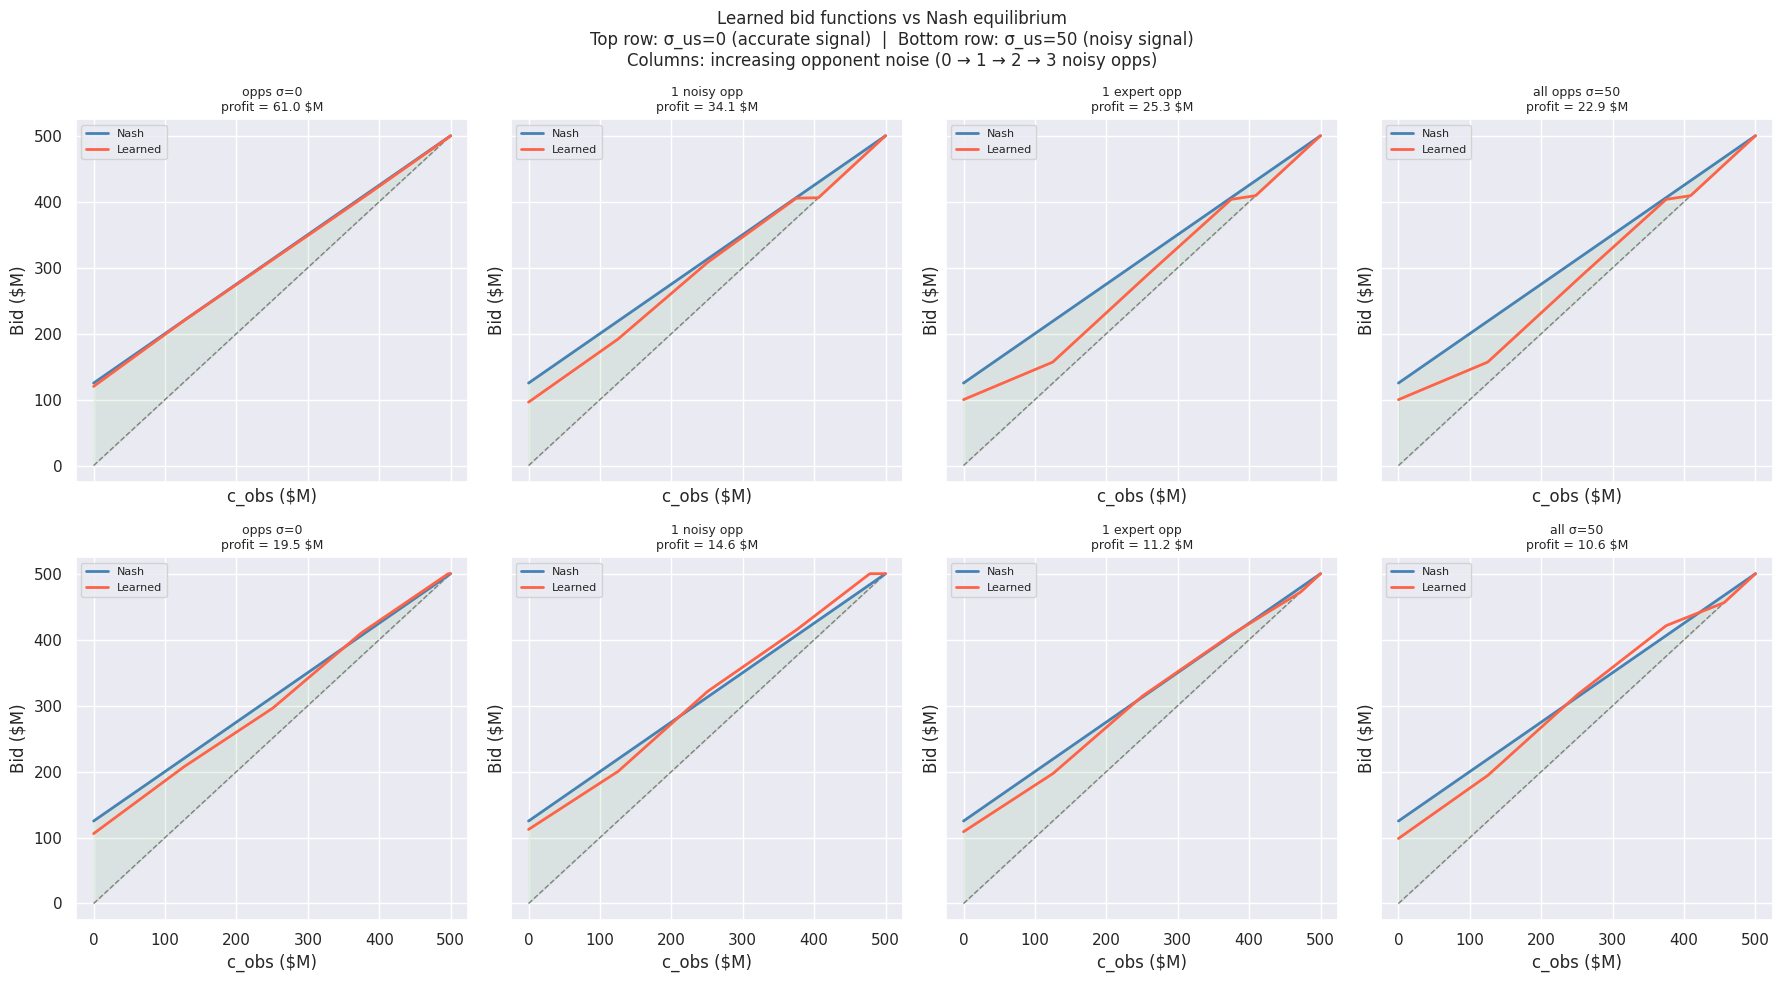


Scenario                            x[0]    seg1    seg2    seg3    seg4  profit
Nash baseline                      1.000   0.750   0.750   0.750   0.750  (ref)
----------------------------------------------------------------------------------------


σ_us=0 | opps σ=0                  0.959   0.789   0.744   0.742   0.762  60.9803


σ_us=0 | 1 noisy opp               0.768   0.763   0.927   0.784   0.020  34.0695


σ_us=0 | 1 expert opp              0.799   0.456   0.997   0.976   0.161  25.2562


σ_us=0 | all opps σ=50             0.799   0.456   0.997   0.976   0.161  22.8575


σ_us=50 | opps σ=0                 0.847   0.802   0.713   0.920   0.737  19.4837


σ_us=50 | 1 noisy opp              0.898   0.701   0.968   0.749   0.830  14.6433


σ_us=50 | 1 expert opp             0.870   0.704   0.939   0.747   0.667  11.2238


σ_us=50 | all σ=50                 0.788   0.764   0.976   0.842   0.429  10.6345


In [17]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10), sharex=True, sharey=True)
fig.suptitle('Learned bid functions vs Nash equilibrium\n'
             'Top row: σ_us=0 (accurate signal)  |  Bottom row: σ_us=50 (noisy signal)\n'
             'Columns: increasing opponent noise (0 → 1 → 2 → 3 noisy opps)',
             fontsize=12)

c_plot   = np.linspace(0, C_max, 300)
b_nash_p = c_plot + (C_max - c_plot) / N

for ax, (name, label, kw) in zip(axes.flat, SCENARIOS_LIST):
    of_s        = AuctionBidding(k=4, N_opps=3, **kw)
    clean_prof  = [of_s.clean_eval(r['best_x']) for r in s3_results[name]]
    best_idx    = int(np.argmax(clean_prof))          # verified best, not luckiest draw
    x_best      = s3_results[name][best_idx]['best_x']
    best_profit = clean_prof[best_idx]

    ax.fill_between(c_plot, c_plot, b_nash_p, alpha=0.07, color='green')
    ax.plot(c_plot, c_plot,   '--', color='grey',      lw=1)
    ax.plot(c_plot, b_nash_p,  '-',  color='steelblue', lw=2, label='Nash')
    ax.plot(c_plot, bid_curve(of0, x_best, c_plot),
                               '-',  color='tomato',   lw=2, label='Learned')
    short_label = label.split('|')[1].strip()
    ax.set_title(f'{short_label}\nprofit = {best_profit:.1f} $M', fontsize=9)
    ax.set_xlabel('c_obs ($M)')
    ax.set_ylabel('Bid ($M)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Per-segment slopes table
nash_x = of0.x_nash
print(f"\n{'Scenario':<32} {'x[0]':>7} {'seg1':>7} {'seg2':>7} {'seg3':>7} {'seg4':>7}  profit")
print(f"{'Nash baseline':<32} " + " ".join(f"{v:7.3f}" for v in nash_x) + "  (ref)")
print('-' * 88)
for name, label, kw in SCENARIOS_LIST:
    of_s        = AuctionBidding(k=4, N_opps=3, **kw)
    clean_prof  = [of_s.clean_eval(r['best_x']) for r in s3_results[name]]
    best_idx    = int(np.argmax(clean_prof))
    x_best      = s3_results[name][best_idx]['best_x']
    best_profit = clean_prof[best_idx]
    print(f"{label:<32} " + " ".join(f"{v:7.3f}" for v in x_best) + f"  {best_profit:.4f}")

σ=0 learned slopes ≈ Nash (0.75). Noisy markets → higher intercept and steeper low-cost segments where underestimation risk is highest.

_Note: with σ_us=0 and mostly-noisy opponents, two scenarios can share the same best row — FSA is seeded identically per run, so similar markets yield the same per-seed winner (the markets still differ: the same strategy scores 25.3 vs 22.9 $M)._

## Section 6 — Summary

Verified profit (FSA `best_x` re-scored at M=100k) vs Nash, per scenario:

| Scenario | σ_us | Opp noise | Profit vs Nash (verified) | Strategy |
|---|---|---|---|---|
| opps σ=0 | 0 | none | −4% (Nash optimal, precision-limited) | ≈ Nash |
| 1 noisy opp | 0 | mild | ≈ Nash (0%) | slight overbid |
| 1 expert opp | 0 | moderate | **+8%** | steepen mid-cost, drop high-cost |
| all opps σ=50 | 0 | strong | **+60%** | exploit opponents' curse |
| opps σ=0 | 50 | none | ≈ Nash (+1%) | large markup |
| 1 noisy opp | 50 | mixed | +2% | selective overbid |
| 1 expert opp | 50 | strong | +4% | aggressive markup |
| all σ=50 | 50 | extreme | +2% | symmetric overbid |

1. **Guided search is necessary** — FSA/GO/DE tie (~58–59 $M), RS fails; FSA chosen for simplicity.
2. **Nash is beatable when noise breaks it** — FSA exploits noisy opponents' winner's curse (+8% to +60%); at σ=0 it correctly can't beat Nash.
3. **Own signal quality dominates** — a noisy own signal collapses profit more (61→17 $M) than noisy opponents do.
4. **The oracle is noisy** — all conclusions are verified via `clean_eval` (M=100k); in-search REL overstates reliability ~5×.

## Appendix — Why Expected Value is Not Enough

EV maximisation ignores variance. For companies bidding on 1–10 contracts/year, a single loss-making win can wipe out the year. Below: per-auction profit distribution and annual outcome simulation under the Nash strategy.

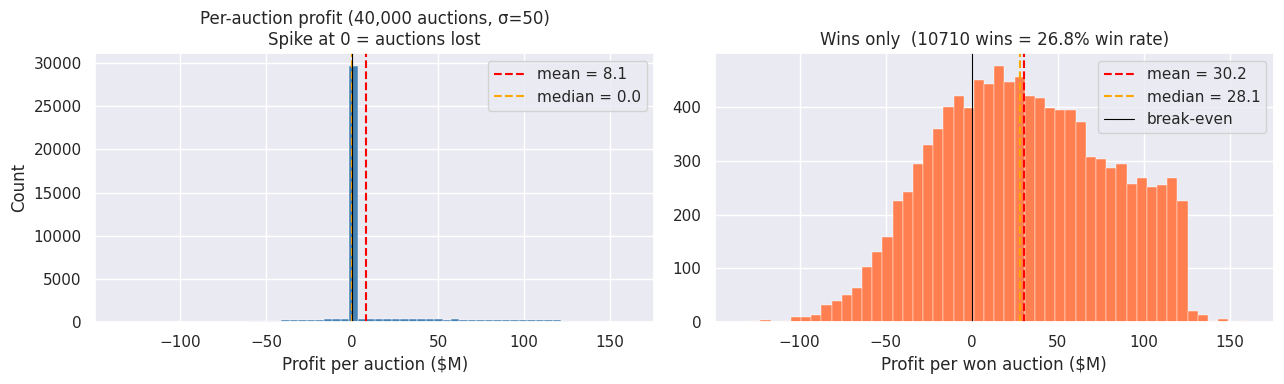

Of 10710 wins: 3176 (29.7%) are loss-making (winner's curse)


In [18]:
# Per-auction profit distribution for Nash strategy in the noisy market
of_demo = AuctionBidding(k=4, N_opps=3, sigma_us=50, sigma_opps=[50, 50, 50], M=40000)
profits_raw = of_demo._mc_raw(of_demo.x_nash)
wins = profits_raw[profits_raw != 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.hist(profits_raw, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(profits_raw.mean(), color='red',    linestyle='--', label=f'mean = {profits_raw.mean():.1f}')
ax.axvline(np.median(profits_raw), color='orange', linestyle='--', label=f'median = {np.median(profits_raw):.1f}')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Profit per auction ($M)')
ax.set_ylabel('Count')
ax.set_title(f'Per-auction profit ({len(profits_raw):,} auctions, σ=50)\nSpike at 0 = auctions lost')
ax.legend()

ax = axes[1]
ax.hist(wins, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax.axvline(wins.mean(),   color='red',    linestyle='--', label=f'mean = {wins.mean():.1f}')
ax.axvline(np.median(wins), color='orange', linestyle='--', label=f'median = {np.median(wins):.1f}')
ax.axvline(0, color='black', linewidth=0.8, label='break-even')
ax.set_xlabel('Profit per won auction ($M)')
ax.set_title(f'Wins only  ({len(wins)} wins = {len(wins)/len(profits_raw)*100:.1f}% win rate)')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Of {len(wins)} wins: {(wins < 0).sum()} ({(wins < 0).mean()*100:.1f}%) are loss-making (winner's curse)")

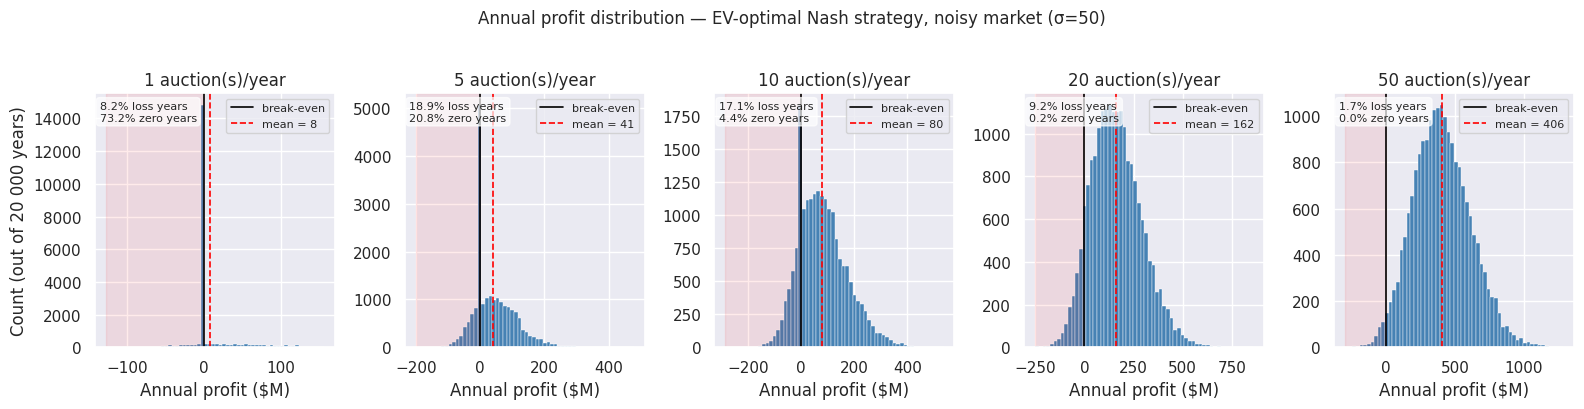

In [19]:
# ── Plot 1: annual profit distributions for increasing auction volume ─────────
N_PER_YEAR_LIST = [1, 5, 10, 20, 50]
rng_sim = np.random.default_rng(0)
N_YEARS = 20_000

annual_by_n = {}
for n in N_PER_YEAR_LIST:
    annual_by_n[n] = np.array([
        profits_raw[rng_sim.integers(0, len(profits_raw), n)].sum()
        for _ in range(N_YEARS)
    ])

fig, axes = plt.subplots(1, len(N_PER_YEAR_LIST), figsize=(16, 4), sharey=False)
for ax, n in zip(axes, N_PER_YEAR_LIST):
    a = annual_by_n[n]
    pct_loss    = (a < 0).mean() * 100
    pct_zero    = (a == 0).mean() * 100   # won nothing at all
    mean_profit = a.mean()
    ax.hist(a, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axvline(0,           color='black',  linewidth=1.2, label='break-even')
    ax.axvline(mean_profit, color='red',    linewidth=1.2, linestyle='--',
               label=f'mean = {mean_profit:.0f}')
    ax.set_title(f'{n} auction(s)/year')
    ax.set_xlabel('Annual profit ($M)')
    neg_patch = ax.axvspan(a.min() - 1, 0, alpha=0.08, color='red')
    ax.text(0.02, 0.97, f'{pct_loss:.1f}% loss years\n{pct_zero:.1f}% zero years',
            transform=ax.transAxes, va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
    ax.legend(fontsize=8)
axes[0].set_ylabel('Count (out of 20 000 years)')
plt.suptitle('Annual profit distribution — EV-optimal Nash strategy, noisy market (σ=50)',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

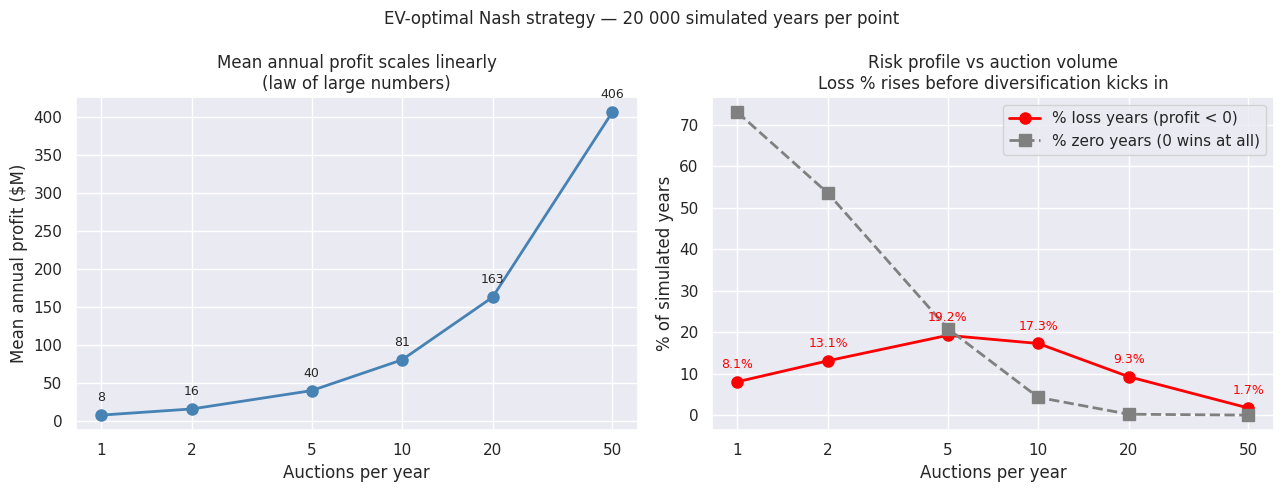

Key insight: with few auctions/year, most years you simply win nothing (grey line).
As volume grows, 'zero years' drop but 'loss years' initially RISE because you now
participate enough to accumulate loss-making wins before diversification helps.


In [20]:
# ── Plot 2: how mean profit and loss-year % change with auction volume ────────
N_VALUES = [1, 2, 5, 10, 20, 50]
rng_sum = np.random.default_rng(1)
N_YEARS2 = 20_000

means, loss_pcts, zero_pcts = [], [], []
for n in N_VALUES:
    annual = np.array([
        profits_raw[rng_sum.integers(0, len(profits_raw), n)].sum()
        for _ in range(N_YEARS2)
    ])
    means.append(annual.mean())
    loss_pcts.append((annual < 0).mean() * 100)
    zero_pcts.append((annual == 0).mean() * 100)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean annual profit
ax1.plot(N_VALUES, means, 'o-', color='steelblue', linewidth=2, markersize=8)
for x, y in zip(N_VALUES, means):
    ax1.annotate(f'{y:.0f}', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9)
ax1.set_xlabel('Auctions per year')
ax1.set_ylabel('Mean annual profit ($M)')
ax1.set_title('Mean annual profit scales linearly\n(law of large numbers)')
ax1.set_xscale('log')
ax1.set_xticks(N_VALUES); ax1.set_xticklabels(N_VALUES)

# Right: % of years in loss and % zero
ax2.plot(N_VALUES, loss_pcts, 'o-', color='red',   linewidth=2, markersize=8, label='% loss years (profit < 0)')
ax2.plot(N_VALUES, zero_pcts, 's--', color='grey',  linewidth=2, markersize=8, label='% zero years (0 wins at all)')
for x, y in zip(N_VALUES, loss_pcts):
    ax2.annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                 xytext=(0, 10), ha='center', fontsize=9, color='red')
ax2.set_xlabel('Auctions per year')
ax2.set_ylabel('% of simulated years')
ax2.set_title('Risk profile vs auction volume\nLoss % rises before diversification kicks in')
ax2.set_xscale('log')
ax2.set_xticks(N_VALUES); ax2.set_xticklabels(N_VALUES)
ax2.legend()
plt.suptitle('EV-optimal Nash strategy — 20 000 simulated years per point', fontsize=12)
plt.tight_layout()
plt.show()

print("Key insight: with few auctions/year, most years you simply win nothing (grey line).")
print("As volume grows, 'zero years' drop but 'loss years' initially RISE because you now")
print("participate enough to accumulate loss-making wins before diversification helps.")

With 1 auction/year most years = 0 profit (no win). Loss years peak at 5–20 auctions as winner's curse accumulates before diversification helps.

alpha sweep:   0%|          | 0/9 [00:00<?, ?it/s]

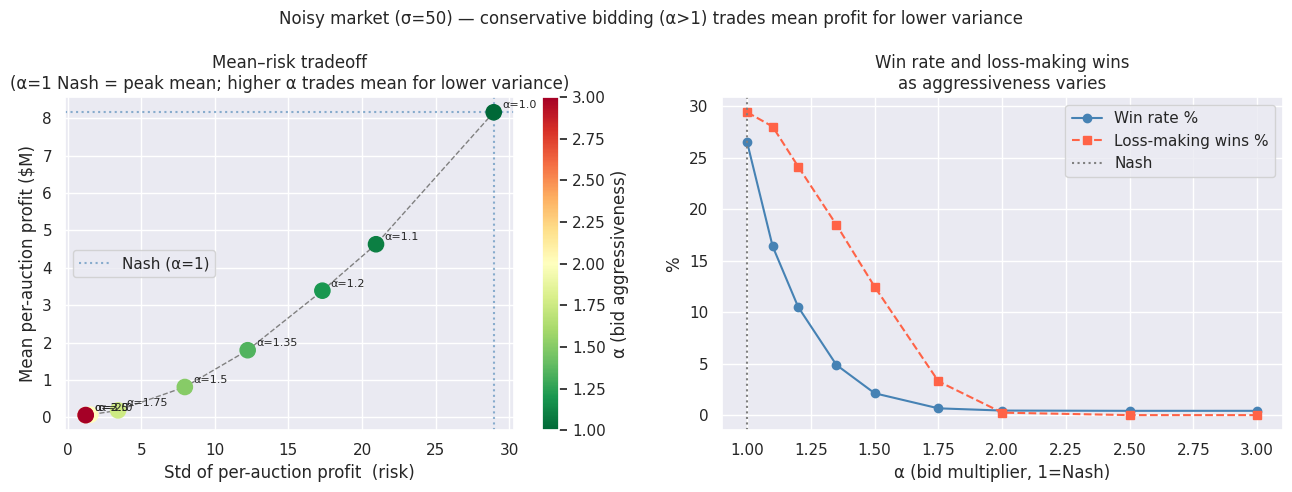


Nash (α=1): mean=8.16, std=28.95, win rate=26.5%, loss wins=29.4%


In [21]:
# Mean-risk tradeoff — analytical, no optimization noise
# We vary bid aggressiveness by scaling the profit margin above Nash:
#   alpha < 1 → bid closer to cost (aggressive, wins more, smaller margin)
#   alpha = 1 → Nash strategy
#   alpha > 1 → bid higher (conservative, wins less, larger margin per win)
# x[0] encodes the intercept; slopes stay at Nash level.

of_noisy = AuctionBidding(k=4, N_opps=3, sigma_us=50, sigma_opps=[50,50,50], M=40000)
alphas = [1.0, 1.1, 1.2, 1.35, 1.5, 1.75, 2.0, 2.5, 3.0]
N_DRAWS = 50   # independent MC draws per alpha for stable mean/std

mean_pts, std_pts = [], []
for alpha in tqdm(alphas, desc='alpha sweep'):
    x = of_noisy.x_nash.copy()
    x[0] = alpha          # scale intercept; alpha=1 → Nash
    draws = [of_noisy._mc_raw(x) for _ in range(N_DRAWS)]
    all_profits = np.concatenate(draws)
    mean_pts.append(all_profits.mean())
    std_pts.append(all_profits.std())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Pareto frontier
ax = axes[0]
sc = ax.scatter(std_pts, mean_pts, c=alphas, cmap='RdYlGn_r', s=120, zorder=3)
for i, a in enumerate(alphas):
    ax.annotate(f'α={a}', (std_pts[i], mean_pts[i]),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.plot(std_pts, mean_pts, '--', color='grey', linewidth=1, zorder=2)
ax.axvline(std_pts[alphas.index(1.0)], color='steelblue', linestyle=':', alpha=0.6, label='Nash (α=1)')
ax.axhline(mean_pts[alphas.index(1.0)], color='steelblue', linestyle=':', alpha=0.6)
plt.colorbar(sc, ax=ax, label='α (bid aggressiveness)')
ax.set_xlabel('Std of per-auction profit  (risk)')
ax.set_ylabel('Mean per-auction profit ($M)')
ax.set_title('Mean–risk tradeoff\n(α=1 Nash = peak mean; higher α trades mean for lower variance)')
ax.legend()

# Right: win rate vs alpha
ax = axes[1]
win_rates, neg_win_rates = [], []
for alpha in alphas:
    x = of_noisy.x_nash.copy()
    x[0] = alpha
    draws = np.concatenate([of_noisy._mc_raw(x) for _ in range(N_DRAWS)])
    win_rates.append((draws != 0).mean() * 100)
    wins = draws[draws != 0]
    neg_win_rates.append((wins < 0).mean() * 100 if len(wins) > 0 else 0)

ax.plot(alphas, win_rates,     'o-', color='steelblue', label='Win rate %')
ax.plot(alphas, neg_win_rates, 's--', color='tomato',   label='Loss-making wins %')
ax.axvline(1.0, color='grey', linestyle=':', label='Nash')
ax.set_xlabel('α (bid multiplier, 1=Nash)')
ax.set_ylabel('%')
ax.set_title('Win rate and loss-making wins\nas aggressiveness varies')
ax.legend()

plt.suptitle('Noisy market (σ=50) — conservative bidding (α>1) trades mean profit for lower variance', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nNash (α=1): mean={mean_pts[alphas.index(1.0)]:.2f}, std={std_pts[alphas.index(1.0)]:.2f}, "
      f"win rate={win_rates[alphas.index(1.0)]:.1f}%, loss wins={neg_win_rates[alphas.index(1.0)]:.1f}%")

**Risk–return tradeoff (α-sweep):** α=1 is Nash (peak mean). α>1 trades mean profit for lower variance — fewer loss-making wins per year.

Choose α based on bid frequency: high α for infrequent bidders, α≈1 for large firms with many parallel contracts.